# Flood-mask EDA for the five Aweil counties
Imad's EDA - Northern Bahr el Ghazal, 2000-2025

We use the satellite flood masks to explore where flooding is detected, when it happens during the year, and how large the detected area is. We also look at consecutive weeks with detections in each county.

This should help us prepare the flood data for the group's forecasting and food-security analysis. It does not yet tell us how long individual fields were flooded or how much crop damage there was.

Run all cells using the project environment. The [README](README.md) explains how to run the notebook and what the output files contain.

## How we process the data
We use both flood classes for each year from 2000 to 2025. This gives 52 Parquet files. All five counties fit inside tile `h20v08`, so we only load that tile.

The main steps are:

1. Filter the data to the study area using a bounding box.
2. Use the Admin-2 boundaries to find the county of each pixel. We count a whole pixel if its centre is inside the county. Pixels on county borders are not split between counties.
3. Calculate pixel area using the grid described in the [NASA user guide, Table 5 on page 28](../literature/MCDWD_VCDWD_UserGuide_RevF.pdf). The grid step is 10/4800 degrees and the product uses a sphere with a radius of 6,371,007.181 m. At 9 degrees N, a pixel covers about 0.0530 km².
4. Group detections into weeks from Monday to Sunday. Each pixel counts once in the weekly total, even if it appears on several dates or in both flood classes.
5. Calculate monthly averages and group consecutive weeks with detections in the same county.

The weekly area includes all pixels detected at some point during that week. This is called a **union**. Those pixels were not necessarily flooded at the same time.

The source data uses three-day composites, which combine observations over three days. These periods overlap, so counting dates with detections does not give the exact number of days a location was under water.

In [1]:
from pathlib import Path
import sys
import calendar

# The workspace can be opened at the project folder or one folder above it.
folders = [Path.cwd()] + list(Path.cwd().parents)
candidates = folders.copy()
for folder in folders:
    candidates.append(folder / "JBG060_ZHL_2026")
PROJECT_ROOT = None
for folder in candidates:
    if (folder / "EDA_flood_masks" / "flood_eda.py").is_file():
        PROJECT_ROOT = folder
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Cannot find JBG060_ZHL_2026 from {Path.cwd()}. Open the project folder first."
    )
if not (PROJECT_ROOT / "raw_data").is_dir():
    raise FileNotFoundError(f"Place the supplied datasets in {PROJECT_ROOT / 'raw_data'}.")

print(f"Python kernel: {sys.executable}")
if sys.version_info < (3, 12):
    raise ImportError("Use Python 3.12 or newer and install requirements.txt.")

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from EDA_flood_masks.check_flood_eda import run_checks
from EDA_flood_masks.flood_eda import (
    YEARS,
    find_detected_events,
    load_flood_observations,
    load_study_counties,
    summarise_seasonality,
    summarise_weekly,
    validate_outputs,
)

TABLE_DIR = PROJECT_ROOT / "EDA_flood_masks" / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "EDA_flood_masks" / "outputs" / "figures"
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
run_checks()

Python kernel: C:\Users\ezzam\Desktop\Capstone Data Challenge\.venv\Scripts\python.exe
Passed: class overlap, repeated days, cell area, gaps, monthly means and single-class data.


In [2]:
boundaries_path = PROJECT_ROOT / "raw_data" / "Administrative boundaries" / "ssd_admin2.geojson"
flood_root = PROJECT_ROOT / "raw_data" / "flood_masks"

counties = load_study_counties(boundaries_path).sort_values("county").reset_index(drop=True)
observations = load_flood_observations(flood_root, counties)
weekly = summarise_weekly(observations)
weekly_by_type = summarise_weekly(observations, by_type=True)
events = find_detected_events(weekly)
seasonality = summarise_seasonality(weekly, counties["county"])
validate_outputs(observations, weekly)

period = f"{observations['date'].min():%d %b %Y} – {observations['date'].max():%d %b %Y}"
print(f"{len(counties)} counties | {len(observations):,} source detections")
print(f"Dates with detections: {period}")
print(f"{len(weekly):,} county-weeks with detections | {len(events)} county detection runs")

5 counties | 972,588 source detections
Dates with detections: 21 Oct 2000 – 21 Dec 2025
1,457 county-weeks with detections | 357 county detection runs


## 1. Checking the data
We first check how many records there are per county and flood class, the dates of the first and last detections, and the cloud values.

The files only contain detected floods. They do not tell us how often the satellite had a clear view of the area. All `cloud_frac` values are zero in this dataset, so we cannot use that column to correct for clouds.

We also check how many pixels appear in both flood classes within the same week. These pixels should only count once in the total area.

In [3]:
coverage = observations.groupby(["county", "flood_type"], observed=True).agg(
    detections=("date", "size"),
    first_detection=("date", "min"),
    last_detection=("date", "max"),
    mean_cloud_fraction=("cloud_frac", "mean"),
).reset_index()
display(coverage)
print("Unique cloud_frac values:", observations["cloud_frac"].unique())

class_cells = weekly_by_type.groupby(["county", "week"])["unique_grid_cells"].sum()
total_cells = weekly.set_index(["county", "week"])["unique_grid_cells"]
overlap = class_cells - total_cells
print(f"Pixels appearing in both classes within a week: {int(overlap.sum()):,} pixel-weeks")
print(f"County-weeks with this overlap: {int(overlap.gt(0).sum())}")

Unique cloud_frac values: [0.]
Pixels appearing in both classes within a week: 3,004 pixel-weeks
County-weeks with this overlap: 83


,county,flood_type,detections,first_detection,last_detection,mean_cloud_fraction
0,Aweil Centre,recurring,8099,2000-10-21,2025-10-29,0.0
1,Aweil Centre,unusual,29835,2000-10-21,2025-12-17,0.0
2,Aweil East,recurring,283383,2000-10-30,2025-12-13,0.0
3,Aweil East,unusual,180738,2001-08-21,2025-12-21,0.0
4,Aweil North,recurring,2549,2001-10-02,2025-10-29,0.0
5,Aweil North,unusual,13439,2001-08-21,2025-11-11,0.0
6,Aweil South,recurring,184559,2001-10-02,2025-12-13,0.0
7,Aweil South,unusual,193964,2000-11-23,2025-12-13,0.0
8,Aweil West,recurring,14948,2000-10-30,2025-11-08,0.0
9,Aweil West,unusual,61074,2001-08-21,2025-11-11,0.0


## 2. Where are floods detected?
Each point on the map is a satellite grid location. Four colour groups show how often flooding was detected there. Both flood types are included in this overview.

An empty part of the map means there are no detections in the data. Flooding could still have been missed there.

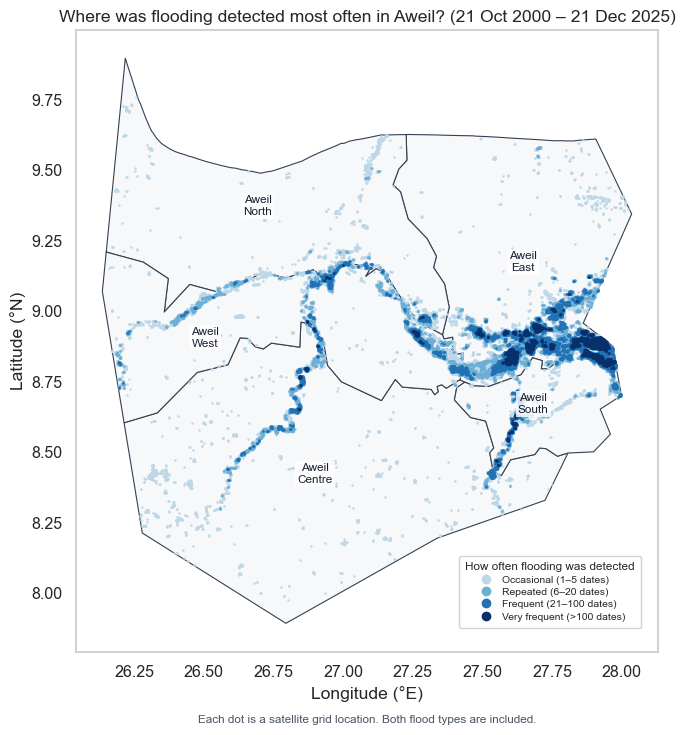

In [4]:
from matplotlib.lines import Line2D

unique_detections = observations.drop_duplicates(["date", "lat", "lon"])
frequency = unique_detections.groupby(["lat", "lon"], observed=True).size()
frequency = frequency.reset_index(name="detected_dates")
frequency_groups = {
    "Occasional (1–5 dates)": (1, 5, "#bdd7e7"),
    "Repeated (6–20 dates)": (6, 20, "#6baed6"),
    "Frequent (21–100 dates)": (21, 100, "#2171b5"),
    "Very frequent (>100 dates)": (101, float("inf"), "#08306b"),
}
labels = counties.geometry.representative_point()
fig, axis = plt.subplots(figsize=(8.5, 7), layout="constrained")
counties.plot(ax=axis, facecolor="#f6f8fa", edgecolor="#354052", linewidth=0.8)
legend_handles = []
for label, (minimum, maximum, colour) in frequency_groups.items():
    subset = frequency[frequency["detected_dates"].between(minimum, maximum)]
    axis.scatter(subset["lon"], subset["lat"], s=3, color=colour, linewidths=0)
    legend_handles.append(Line2D([], [], marker="o", linestyle="", color=colour, label=label))
for county, point in zip(counties["county"], labels):
    axis.annotate(
        county.replace(" ", "\n", 1), (point.x, point.y), ha="center", va="center",
        fontsize=8.5, color="#182233",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 1.5},
    )
axis.legend(
    handles=legend_handles, title="How often flooding was detected",
    loc="lower right", bbox_to_anchor=(0.98, 0.03), fontsize=7.5, title_fontsize=8.5,
    handletextpad=0.5, labelspacing=0.3, borderpad=0.6, framealpha=0.9,
)
axis.set(title=f"Where was flooding detected most often in Aweil? ({period})",
         xlabel="Longitude (°E)", ylabel="Latitude (°N)")
axis.grid(False)
fig.text(
    0.5, -0.025, "Each dot is a satellite grid location. Both flood types are included.",
    ha="center", fontsize=8.5, color="#495366",
)
fig.savefig(FIGURE_DIR / "flood_detection_frequency.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## 3. Which months have the most detected flooding?
The heatmap shows the typical detected area in a week for each month, in km².

We first calculate a monthly average for each year and then combine the 26 years. This stops years with more observations from automatically receiving more weight. A week belongs to the month of its Monday.

Weeks with no records are counted as zero detections. This does not prove that the land was dry because the satellite may also have missed flooding. The CSV includes the number of years and weeks used in each average.

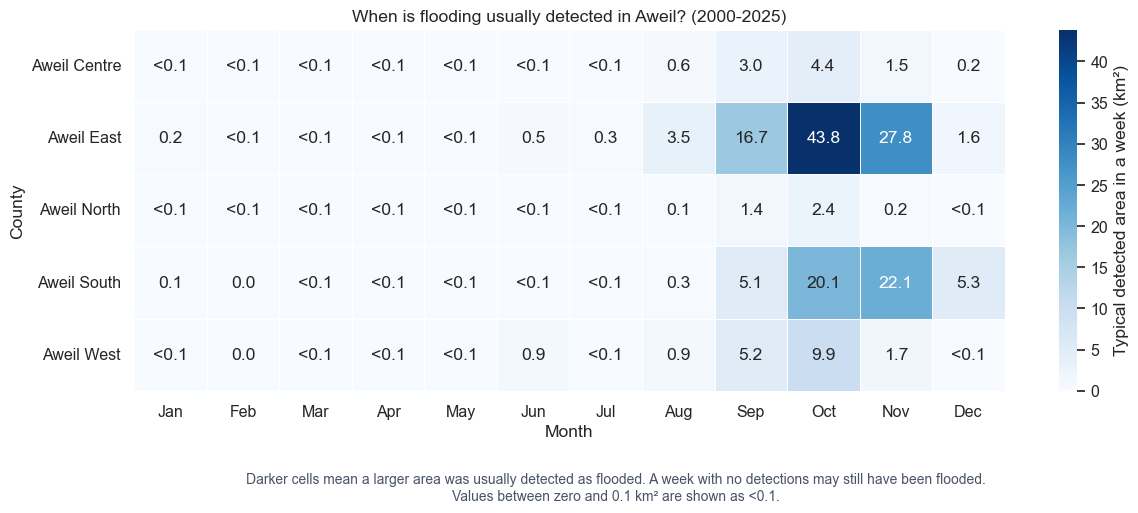

In [5]:
heatmap = seasonality.pivot(
    index="county", columns="month", values="mean_weekly_detected_area_km2"
).reindex(columns=range(1, 13))
# Small positive values should not look like zero after rounding.
annotations = heatmap.astype(str)
for county in heatmap.index:
    for month in heatmap.columns:
        value = heatmap.loc[county, month]
        if 0 < value < 0.1:
            annotations.loc[county, month] = "<0.1"
        else:
            annotations.loc[county, month] = f"{value:.1f}"
fig, axis = plt.subplots(figsize=(12.5, 5.2))
sns.heatmap(
    heatmap, ax=axis, cmap="Blues", vmin=0, annot=annotations, fmt="",
    linewidths=0.5, linecolor="white",
    xticklabels=[calendar.month_abbr[month] for month in heatmap.columns],
    cbar_kws={"label": "Typical detected area in a week (km²)"},
)
axis.set(
    title=f"When is flooding usually detected in Aweil? ({min(YEARS)}-{max(YEARS)})",
    xlabel="Month", ylabel="County",
)
axis.tick_params(axis="x", rotation=0)
fig.text(
    0.5, 0.02, "Darker cells mean a larger area was usually detected as flooded. A week with no detections may still have been flooded.\n"
    "Values between zero and 0.1 km² are shown as <0.1.",
    ha="center", fontsize=10, color="#495366",
)
fig.tight_layout(rect=(0, 0.1, 1, 1))
fig.savefig(FIGURE_DIR / "monthly_seasonality.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## 4. How large and long were the detections?
The bars show the largest detected area in one week and the longest run of weeks with detections for every Aweil county.

Because this is measured at county level, detections in consecutive weeks can come from different parts of the county. This does not prove that one field stayed flooded for the whole period.

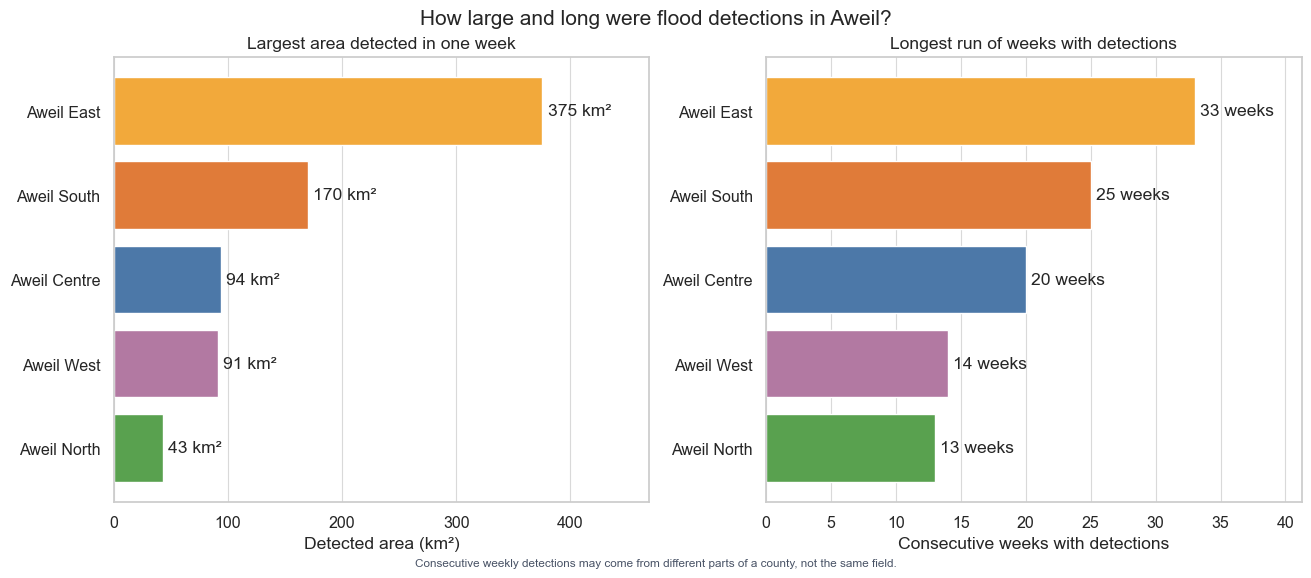

,detection_run_count,median_county_detected_weeks,longest_county_detected_weeks,largest_weekly_union_area_km2
county,,,,
Aweil East,98,2.0,33,375.26
Aweil South,50,4.0,25,169.81
Aweil Centre,82,2.0,20,93.65
Aweil West,71,2.0,14,91.06
Aweil North,56,1.0,13,42.85


In [6]:
event_summary = events.groupby("county", observed=True).agg(
    detection_run_count=("run_id", "size"),
    median_county_detected_weeks=("county_detected_weeks", "median"),
    longest_county_detected_weeks=("county_detected_weeks", "max"),
    largest_weekly_union_area_km2=("peak_weekly_union_area_km2", "max"),
).sort_values("largest_weekly_union_area_km2", ascending=False)
plot_summary = event_summary.reset_index().sort_values("largest_weekly_union_area_km2")
county_colours = {
    "Aweil Centre": "#4c78a8", "Aweil East": "#f2a93b",
    "Aweil North": "#59a14f", "Aweil South": "#e07b39",
    "Aweil West": "#b279a2",
}
colours = [county_colours[county] for county in plot_summary["county"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), layout="constrained")
bars = axes[0].barh(plot_summary["county"], plot_summary["largest_weekly_union_area_km2"], color=colours)
axes[0].bar_label(bars, labels=[f"{value:.0f} km²" for value in plot_summary["largest_weekly_union_area_km2"]], padding=4)
axes[0].set(title="Largest area detected in one week", xlabel="Detected area (km²)", ylabel="")
axes[0].set_xlim(0, plot_summary["largest_weekly_union_area_km2"].max() * 1.25)
bars = axes[1].barh(plot_summary["county"], plot_summary["longest_county_detected_weeks"], color=colours)
axes[1].bar_label(bars, labels=[f"{value:.0f} weeks" for value in plot_summary["longest_county_detected_weeks"]], padding=4)
axes[1].set(title="Longest run of weeks with detections", xlabel="Consecutive weeks with detections", ylabel="")
axes[1].set_xlim(0, plot_summary["longest_county_detected_weeks"].max() * 1.25)
for axis in axes:
    axis.grid(axis="x", visible=True, color="#d9d9d9", linewidth=0.8)
    axis.grid(axis="y", visible=False)
    axis.set_axisbelow(True)
fig.suptitle("How large and long were flood detections in Aweil?", fontsize=15)
fig.text(0.5, -0.02, "Consecutive weekly detections may come from different parts of a county, not the same field.", ha="center", fontsize=8.5, color="#495366")
fig.savefig(FIGURE_DIR / "event_size_duration.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)
display(event_summary.round(2))

## 5. What do we find?
The results below are calculated from the tables above, so they update when the notebook runs.

We compare detected areas in km². We have not adjusted these results for county size, cloud cover, farmland or population. Those factors are needed before we can say more about local flood risk and impacts.

In [7]:
peak = events.loc[events["peak_weekly_union_area_km2"].idxmax()]
peak_months = seasonality.loc[
    seasonality.groupby("county")["mean_weekly_detected_area_km2"].idxmax()
].sort_values("county")
season_lines = []
for row in peak_months.itertuples():
    line = (
        f"- {row.county}: {calendar.month_name[row.month]}, "
        f"{row.mean_weekly_detected_area_km2:.2f} km² average weekly detected area."
    )
    season_lines.append(line)
season_lines = "\n".join(season_lines)
leader = event_summary.index[0]
display(Markdown(
    f"After selecting the five counties, we have **{len(observations):,} records** "
    f"from {period}.\n\n"
    f"The maps show most detections towards the east and southeast of the study area. "
    f"{leader} has the largest weekly detected area at "
    f"**{peak['peak_weekly_union_area_km2']:.2f} km²**.\n\n"
    f"The month with the highest average in each county is:\n\n{season_lines}\n\n"
    f"We found **{len(events)} county detection runs**. The longest is "
    f"**{int(events['county_detected_weeks'].max())} weeks**. "
    f"The median length per county ranges from "
    f"{event_summary['median_county_detected_weeks'].min():.0f} to "
    f"{event_summary['median_county_detected_weeks'].max():.0f} weeks. "
    f"This tells us about detections across the county, not how long one field was flooded.\n\n"
    f"We also found **{int(overlap.sum()):,} pixel-week combinations** in both flood classes. "
    f"Each of these counts once in the total weekly area."
))

After selecting the five counties, we have **972,588 records** from 21 Oct 2000 – 21 Dec 2025.

The maps show most detections towards the east and southeast of the study area. Aweil East has the largest weekly detected area at **375.26 km²**.

The month with the highest average in each county is:

- Aweil Centre: October, 4.37 km² average weekly detected area.
- Aweil East: October, 43.84 km² average weekly detected area.
- Aweil North: October, 2.42 km² average weekly detected area.
- Aweil South: November, 22.09 km² average weekly detected area.
- Aweil West: October, 9.92 km² average weekly detected area.

We found **357 county detection runs**. The longest is **33 weeks**. The median length per county ranges from 1 to 4 weeks. This tells us about detections across the county, not how long one field was flooded.

We also found **3,004 pixel-week combinations** in both flood classes. Each of these counts once in the total weekly area.

### Limitations and next steps
- `recurring` and `unusual` describe how often flooding has occurred. They do not directly show severity or predictability.
- A week with no detections may be dry, but flooding may also have been missed. The cloud column does not help us separate these cases.
- A weekly area combines pixels from different dates. Consecutive county weeks can also involve different pixels. To study how long fields were flooded, we need to follow the same locations over time and account for missing observations.
- County totals hide local differences. We still need to combine them with crop, rangeland and population data, including the effects on herders who move between areas.
- Before building the forecast, we need to check how the recurrence labels were made. If they use information from later years, this could cause data leakage. The model should be tested on later time periods.
- We need to align the dates of the flood, weather, river, lake, crop and IPC data before combining them. These plots alone cannot show how flooding affects food security.

This notebook covers the satellite-mask EDA. The forecast model and the analysis of food-security impacts are next steps for the group.

## 6. Saving the results
We save the CSV files in `outputs/tables/` and the PNG figures in `outputs/figures/`.

The [README](README.md#output-dictionary) explains the columns and units. Some column names changed after fixing the area and duration calculations, so check the names before using the CSVs in other code.

Use `weekly_county_floods.csv` for total weekly areas. The separate class table can count a pixel in both classes within one week, so its areas should not be added together.

In [8]:
tables = {
    "coverage_summary.csv": coverage,
    "weekly_county_floods.csv": weekly,
    "weekly_county_floods_by_type.csv": weekly_by_type,
    "monthly_seasonality.csv": seasonality,
    "detected_flood_events.csv": events,
    "event_summary_by_county.csv": event_summary.reset_index(),
}
for filename, table in tables.items():
    table.to_csv(TABLE_DIR / filename, index=False)
print(f"Saved {len(tables)} tables to {TABLE_DIR}")
print(f"Saved 3 figures to {FIGURE_DIR}")

Saved 6 tables to C:\Users\ezzam\Desktop\Capstone Data Challenge\JBG060_ZHL_2026\EDA_flood_masks\outputs\tables
Saved 3 figures to C:\Users\ezzam\Desktop\Capstone Data Challenge\JBG060_ZHL_2026\EDA_flood_masks\outputs\figures
